# Memories by Postcards

This is the Jupyter notebook of **Maria Juliana Gamboa Nivia** for the zero sesion exam of the course **Information Visualization** 2025/2026.

I decided for my project to analyze my **Postcard Collection** that I have gathered from my trips around the world in the last 5 years. 
I annotate my personal dataset manually in a CSV (PostcardDataset.csv) where every line is a postcard with their metadata that represents a trip. 

Each Postcard has an identifier (ID), the city where is from (Location_city), the country (Location_Country), what is portrait in the image (Subject_Category), the date of the trip (Date), the person that accompanied me in the trip (With_who), the iconicity of the place, (Iconic Scale) and the value that I give to that place based on my trip  (Memory_scale).

My **Research Question (RQ)** is: How my trips to iconic or famous places were compared to other less famous cities reflect on the positive or negative memory of my trip in that place. I would like to understand what are the factors that make a trip memorable or close to my heart, are the places? the years? or the people that accompanied me on those trips. 

To better understand this I performed three different types of analysis that allowed me to get to my final analysis of my RQ, where I used a Scatter Plot visualization for it.

The different analysis were:
- The amount of trips I have done in the course of the years.
- Who has accompanied me the most in my trips across the years.
- Where are the places that I have visited the most?

The final visualization is the result of my RQ where I compared the iconicness of the place with the positive or negative memory that I had of the trip in that place considering the person that I was with in the trip.

### Trips by Year. Every year more trips ? 

In this first analysis I wanted to see the amount of trips I have done in the last five years, therefore I used the data of the amount of postcards that I have that represented the number of trips and group them by the year I went to that place. 

To perform this analysis, firstly I took the column of my dataset "Date" (month and year of the trip) and stripped the month to have just the Year. Then I group the postcards by their year to be able to create my chart.

I decided to use a **Line Chart** to represent the amount of trips that I have done through the years.
Revealing the tendency that every year that passes I have traveled more, and the year where I went to more places was 2024, yet this year (2026) I have been to several trips and the year has not ended. 

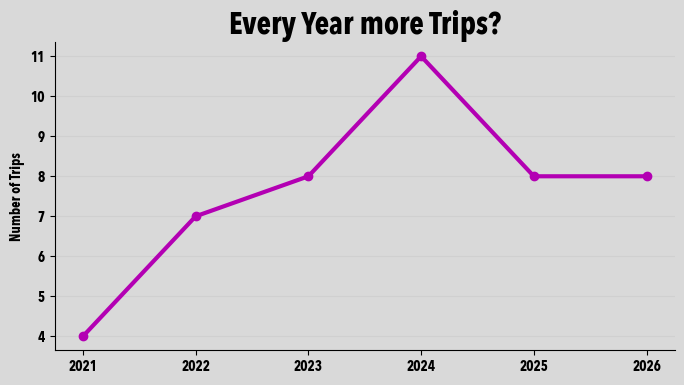

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Dataset
df = pd.read_csv('PostcardDataset.csv')

# strip from date the month to just year 
df["Year"] = df["Date"].astype(str).str.split(" ").str[-1]

#number of trips x year
trips_per_year = df.groupby("Year").size().reset_index(name="trips_x_year")


# line chart 
plt.figure(figsize=(8, 4), facecolor='#d9d9d9')
ax=plt.axes()
plt.plot(
    trips_per_year["Year"],
    trips_per_year["trips_x_year"],
    marker="o",
    color="#b300b3",
    linewidth=3,
    linestyle="-",
)

# style
plt.title("Every Year more Trips?", fontsize=22)
plt.ylabel("Number of Trips")
plt.grid(True, axis='y', linestyle="-", alpha=0.2)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Avenir next condensed']
ax.set_facecolor('#d9d9d9')

# leaves just llines of x and y 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black') # Ensure X and Y lines are visible
ax.spines['bottom'].set_color('black')

# year axis shows just integers 
plt.xticks(trips_per_year["Year"])

# show the chart
plt.show()

## My Travel Partners

In my second analysis I decided to understand who were my most frequent companions or partners of my travels across the years. Therefore I used the data of the people that went with me to the places in the postcards and group them by the years that the postcard correspond to it. 

To perform this analysis I took the column of the dataset "With_who" and the previouslsy made column "Year" and group them together to get the number of trips I have made with each person every year.

I decided to display this analysis with a **Bar Chart** to show who accompanied me in the trips I have dove over the last five years. Revealing that my more frequent partners in my trips were "Ma and Pa" (my parents) since in 2022. 


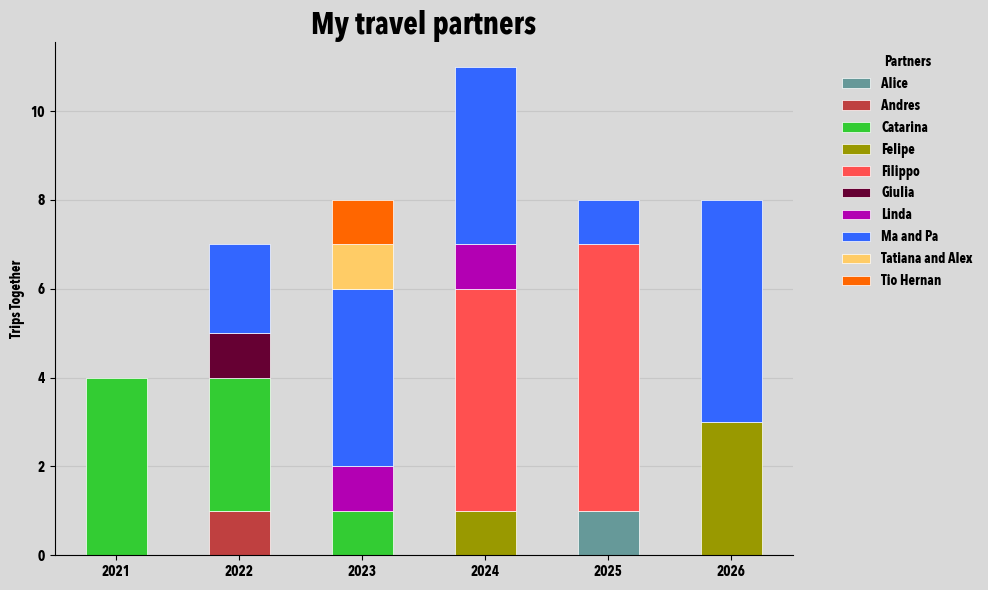

In [2]:
#to make recognice linda and giacomo as linda 
df['With_who'] = df['With_who'].replace('Linda and Giacomo', 'Linda')

#group personas by years of the trips 
counts = (
    df.groupby(["Year", "With_who"])
    .size()
    .reset_index(name="trip_count")
)

# sort by the personas that i have travel the most 
counts = counts.sort_values(by=["Year", "trip_count"], ascending=[True, False])

# clean data para chart
pivot_df = counts.pivot(
    index="Year", columns="With_who", values="trip_count"
).fillna(0)

#Bar Chart 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Avenir next condensed']

colorXperson = {
    'Filippo': '#ff5050',
    'Ma and Pa': '#3366ff',
    'Catarina': '#33cc33',
    'Linda': '#b300b3',
    'Tatiana and Alex': '#ffcc66',
    'Giulia': '#660033',
    'Alice': '#669999',
    'Linda and Giacomo': '#ff66ff',
    'Tio Hernan': '#ff6600',
    'Andres': '#bf4040',
    'Felipe': '#999900'

}

ax = pivot_df.plot(
    kind="bar", 
    stacked=True, 
    figsize=(10, 6), 
    color=colorXperson,
    edgecolor='white', # gap between segments 
    linewidth=0.5
)

# Background Color
ax.set_facecolor('#d9d9d9')
ax.figure.set_facecolor('#d9d9d9')   

# leaves just lines of x and y 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#Style
plt.title("My travel partners", fontsize=22)
plt.ylabel("Trips Together", fontsize=10)
plt.xlabel("")
plt.xticks(rotation=0)

#Legend
plt.legend(title="Partners", bbox_to_anchor=(1.05, 1), frameon=False)

# grid
ax.yaxis.grid(True, linestyle='-', alpha=0.2, color='gray')
ax.set_axisbelow(True) #lines behind the bars

plt.tight_layout()
plt.show()


## Around the World 

In my third analysis I decided to visualize where I have been arround the world, the countries that I have visited in the last five years and the frecuency that I have visited these places. Therefore I used the data of the places where I bought my postcards during my travels and the amount of times I have been to specific places.

To perform this analysis I took the column of the dataset "Location_Country" and group the postcards (the trips I have done) by the countries to obtain the amount of times I have traveled to each country. 

I decided to display this analysis with a **Geographical Map** to show visually in a world map the geo-localization of the countries that I have visited and the amount of times I have been there. Revealing that the county that I have visited the most in the last 5 years is Italy since I have 9 postcards of different places in Italy, followed by France, Spain and Portugal.


In [ ]:
import plotly.express as px

#change england to UK
df["Location_Country"] = df["Location_Country"].replace({"England": "United Kingdom"})

#group tryps by the countries 
country_counts = df.groupby("Location_Country").size().reset_index(name="trip_count")


# world map chart
fig = px.choropleth(
    country_counts,
    locations="Location_Country",
    locationmode="country names",
    color="trip_count",
    hover_name="Location_Country",
    hover_data={"Location_Country": False, "trip_count": True},
    labels={"trip_count": "Trips"},
    color_continuous_scale="Viridis",
    title="Around the World"
)

# Style
fig.update_layout(
    title={
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(family="Avenir next condensed", size=40, color= 'black', weight='bold' )
    },
    # background colors
    paper_bgcolor="#d9d9d9", 
    geo=dict(
        bgcolor="#d9d9d9",    
        showframe=False,
        showcoastlines=True,
        projection_type="wagner6",
        
        #lataxis_range=[-60, 90], #mas the map bigguers
    ),
    #remove margins
    margin={"r":0,"t":50,"l":0,"b":50},
    height=700, 
    
    #legend
    coloraxis_colorbar=dict(
        title="Intensity of Trips",
        orientation="h",     
        yanchor="bottom",
        y=-0.2,               
        xanchor="center",
        x=0.5,
        len=0.5             
    ),
    font=dict(family="Avenir Next Condensed", color= 'black', weight='bold' )
)

fig.show()

# If the chart does not appear do to problems with the library is available at github at: AroundWorldMap_chart.html
#fig.write_html("AroundWorldMap_chart.html")

/var/folders/g3/dsvv5mvx67n1xxrct5kbw4s40000gn/T/ipykernel_1948/2798146386.py:11: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


# What Truly Makes a Trip? 

My final analysis was performed based on the results of the three previous analyses to be able to fully understand how to develop my research question. 
Therefore to answer the RQ I decided to understand what were the factors that determined how for me a trip to a place becomes memorable or close to my heart, it was the place that I went? Is becaused i go to a famous or not city? The specific year when I traveled? or are the people that I went with?

Since my collection of Postcards of my travels around the world was a way to represent and re-live every trips i have done, I decided to add to my dataset two columns:
- "Iconic_Scale":  were I decided to put in scale from 1 to 10 how much a city is famous, for example cities such as New York and Paris got a 10
- "Memory _scale": were I decided to put in scale from 1 to 10 the close memory that I have of that place, being 10 a very special trip for me. 

To perform my analysis I considered the columns of my dataset "Iconic_Scale", "Memory_scale", "With_who" and "Location_city" (the specific city of the postcard of the trip) to see if there was a trend that explain what makes a memorable trip. 

I decide to visualize this analysis with a **Scatter Plot** visualization since it allows me to represent all the four variables that I wanted to take into consisideration to answer my RQ. 

The Data revealed that it does not matter the places I visited, it could be a famous city such as London or less famous like Nancy, what makes my trip memorable is the people that I went with it. For example I have iconic cities like Tokyo that have a very low value in my memory instead other cities like Volterra are very memorable to me, it does not matter where I go but with who I go. 

Therefore my collection of postcards that allow me to analyse and re-live my travels reveal that I can or not go to famous places and still have beautiful trips and memories of them as long as I go with the right companions.




In [ ]:
#size bubble 
df['tamaño_burbuja'] = 18

#Final Visualization 
colorXperson = {
    'Filippo': '#ff5050',
    'Ma and Pa': '#3366ff',
    'Catarina': '#33cc33',
    'Linda': '#b300b3',
    'Tatiana and Alex': '#ffcc66',
    'Giulia': '#660033',
    'Alice': '#669999',
    'Linda and Giacomo': '#ff66ff',
    'Tio Hernan': '#ff6600',
    'Andres': '#bf4040',
    'Felipe': '#999900'
}

#Scatter plot for final viz
fig = px.scatter(
    df,
    x="Iconic_Scale",  
    y="Memory_scale",  #
    color="With_who", 
    hover_name="Location_City",  
    size="tamaño_burbuja",
    size_max=20,
    color_discrete_map=colorXperson, 
    hover_data={
        "Iconic_Scale": ":.1f",
        "Memory_scale": ":.1f",
        "With_who": True,
        "tamaño_burbuja": False 
    },  
    title="What Truly Makes a Trip? The Place or The People",
)

# style
fig.update_layout(
    paper_bgcolor="#d9d9d9", 
    plot_bgcolor="#d9d9d9",
    height=750,
    font=dict(family="Avenir Next Condensed", color="black"),

    xaxis_title="Iconic scale",
    yaxis_title="Memory scale",
    legend_title="Partners",

    title={
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(family="Avenir next condensed", size=35, color= 'black', weight='bold' )
    }
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor="LightGrey", linewidth=1.5, linecolor='black')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor="LightGrey", linewidth=1.5, linecolor='black')
fig.update_traces(marker=dict(line=dict(width=0)))

# Show final viz
fig.show()

#This to save the chart in html is available on github at: MJGN_chart_infoviz.html
#fig.write_html("MJGN_chart_infoviz.html") 